## Problem Statement


You are a data scientist working for a sports analytics company. The dataset, named **"sports_league_data.csv"** includes a variety of attributes for players in the league. The columns in the dataset are as follows:

- **player_id:** A unique identifier for each player.
- **age:** Age of the player.
- **position:** The position the player typically plays in (e.g., Forward, Midfielder, Defender, Goalkeeper).
- **team:** The team the player belongs to.
- **games_played:** The total number of games played by the player in the season.
- **player_rating:** An overall performance rating for the player for the season.

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Import Necessary Libraries**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

## Task1

1. Import the data from the "sports_league_data.csv" file.
2. display the number of rows and columns. 
3. Display the first few rows of the dataset to get an overview.


In [6]:
df=pd.read_csv("sports_league_data.csv")
print(sports_df.shape)
df.head()

(1000, 6)


,player_id,age,position,team,games_played,player_rating
0,P0001,34,Forward,Team 14,29,7.2
1,P0002,29,Defender,Team 15,27,8.3
2,P0003,31,Goalkeeper,Team 4,39,6.4
3,P0004,36,Goalkeeper,Team 6,35,6.6
4,P0005,34,Defender,Team 14,26,7.2


## Task2:

**Age Analysis:**
- Mean: Calculate the average age of players in the league.
- Standard Deviation Intervals:
    - Calculate the age range within one standard deviation of the mean.
    - Calculate the age range within two standard deviations of the mean.
    - Calculate the age range within three standard deviations of the mean.
  

In [9]:
mean_age=df["age"].mean()
std=df["age"].std()
range1=(mean_age-std,mean_age+std)
range2=(mean_age-2*std,mean_age+2*std)
range3=(mean_age-3*std,mean_age+3*std)

## Task3:

**Player Rating Analysis:**
- Mean: Determine the average player rating across the league.
- Standard Deviation Intervals:
    - Calculate the player rating range within one standard deviation of the mean.
    - Calculate the player rating range within two standard deviations of the mean.
    - Calculate the player rating range within three standard deviations of the mean.

In [10]:
mean_rating=df["player_rating"].mean()
std_rating=df["player_rating"].std()
range1_rating=(mean_rating-std_rating,mean_rating+std_rating)
range2_rating=(mean_rating-2*std_rating,mean_rating+2*std_rating)
range3_rating=(mean_rating-3*std_rating,mean_rating+3*std_rating)

## Task4:

Create histogram with Kernel Density Estimation (KDE) plots for both the 'age' and 'player_rating' columns from the dataset. While constructing these plots, ensure to visually represent the standard deviation intervals on the graph.


- **'age'**

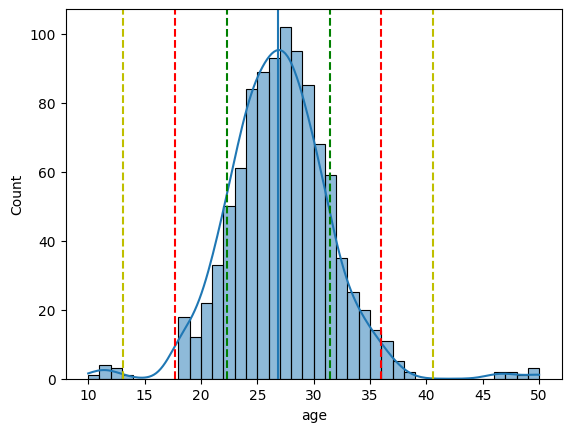

In [34]:
sns.histplot(df["age"], kde=True)
plt.axvline(mean_age, linestyle='-')
plt.axvline(range1[0], linestyle='--',color='g')
plt.axvline(range1[1], linestyle='--',color='g')
plt.axvline(range2[0], linestyle='--',color='r')
plt.axvline(range2[1], linestyle='--',color='r')
plt.axvline(range3[0], linestyle='--',color='y')
plt.axvline(range3[1], linestyle='--',color='y')
plt.show()

- **'player_rating'**

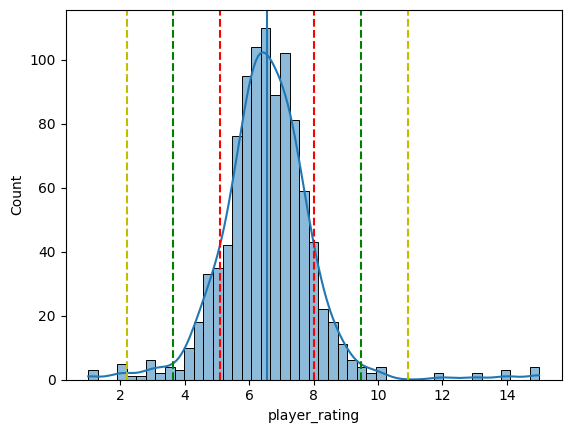

In [35]:
sns.histplot(df["player_rating"], kde=True)
plt.axvline(mean_rating, linestyle='-')
plt.axvline(range1_rating[0], linestyle='--',color='r')
plt.axvline(range1_rating[1], linestyle='--',color='r')
plt.axvline(range2_rating[0], linestyle='--',color='g')
plt.axvline(range2_rating[1], linestyle='--',color='g')
plt.axvline(range3_rating[0], linestyle='--',color='y')
plt.axvline(range3_rating[1], linestyle='--',color='y')
plt.show()

## Task5

- Calculate the lower and upper boundaries for the 'Age' and 'Player_Rating' columns. 
- For each column, identify values that fall outside the calculated lower and upper boundaries. These values are considered outliers.

- **Display age outliers**

In [37]:
df[(df['age']>range3[1]) | (df['age']<range3[0])]

,player_id,age,position,team,games_played,player_rating
66,P0067,11,Midfielder,Team 18,38,6.4
123,P0124,50,Midfielder,Team 11,23,5.9
156,P0157,46,Midfielder,Team 6,16,4.5
207,P0208,10,Forward,Team 15,30,6.0
305,P0306,47,Midfielder,Team 7,22,7.6
376,P0377,11,Defender,Team 16,25,6.1
474,P0475,50,Goalkeeper,Team 4,24,7.4
630,P0631,47,Defender,Team 16,28,6.0
647,P0648,12,Goalkeeper,Team 16,21,6.1
795,P0796,11,Goalkeeper,Team 8,33,7.5


- **Display player_rating outliers**

In [38]:
df[(df['player_rating']>range3_rating[1]) | (df['player_rating']<range3_rating[0])]

,player_id,age,position,team,games_played,player_rating
32,P0033,23,Defender,Team 1,29,2.0
41,P0042,21,Goalkeeper,Team 19,27,13.0
96,P0097,27,Defender,Team 2,37,2.0
116,P0117,31,Goalkeeper,Team 19,25,2.1
194,P0195,29,Forward,Team 6,33,1.0
212,P0213,30,Defender,Team 7,26,15.0
297,P0298,29,Goalkeeper,Team 17,31,2.0
301,P0302,34,Defender,Team 19,30,15.0
315,P0316,27,Midfielder,Team 15,28,13.0
387,P0388,21,Goalkeeper,Team 1,35,14.0


## Task6

-  Remove outliers from both the 'age' and 'player_rating' columns and then visualize the adjusted data using histogram plots.


In [39]:
df=df[(df['player_rating']<range3_rating[1]) & (df['player_rating']>range3_rating[0])]
df=df[(df['age']<range3[1]) & (df['age']>range3[0])]
df

,player_id,age,position,team,games_played,player_rating
0,P0001,34,Forward,Team 14,29,7.2
1,P0002,29,Defender,Team 15,27,8.3
2,P0003,31,Goalkeeper,Team 4,39,6.4
3,P0004,36,Goalkeeper,Team 6,35,6.6
4,P0005,34,Defender,Team 14,26,7.2
...,...,...,...,...,...,...
995,P0996,29,Defender,Team 19,22,7.6
996,P0997,26,Defender,Team 10,39,4.4
997,P0998,27,Forward,Team 8,40,6.4
998,P0999,22,Defender,Team 10,27,6.0


- **plot the histograms**

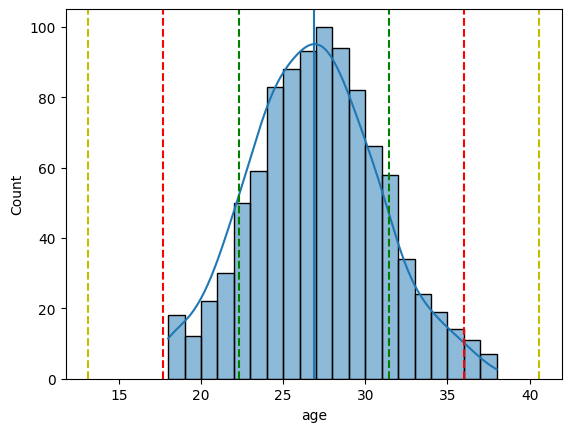

In [40]:
sns.histplot(df["age"], kde=True)
plt.axvline(mean_age, linestyle='-')
plt.axvline(range1[0], linestyle='--',color='g')
plt.axvline(range1[1], linestyle='--',color='g')
plt.axvline(range2[0], linestyle='--',color='r')
plt.axvline(range2[1], linestyle='--',color='r')
plt.axvline(range3[0], linestyle='--',color='y')
plt.axvline(range3[1], linestyle='--',color='y')
plt.show()

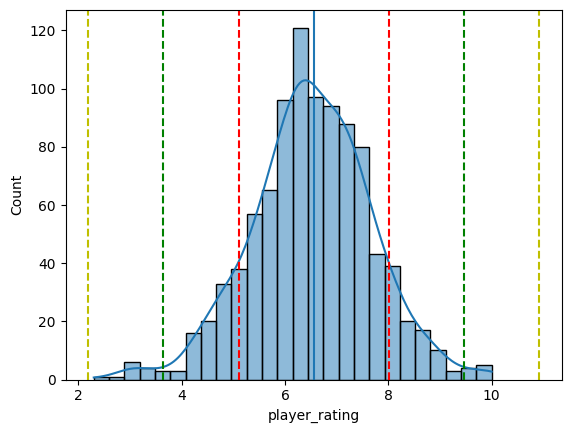

In [41]:
sns.histplot(df["player_rating"], kde=True)
plt.axvline(mean_rating, linestyle='-')
plt.axvline(range1_rating[0], linestyle='--',color='r')
plt.axvline(range1_rating[1], linestyle='--',color='r')
plt.axvline(range2_rating[0], linestyle='--',color='g')
plt.axvline(range2_rating[1], linestyle='--',color='g')
plt.axvline(range3_rating[0], linestyle='--',color='y')
plt.axvline(range3_rating[1], linestyle='--',color='y')
plt.show()